<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Naive Bayes From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Implement Naive Bayes by hand on a small categorical dataset.</li>
<li>Understand where the "naive" independence assumption is actually used.</li>
<li>Build a general-purpose Gaussian Naive Bayes class for continuous data.</li>
<li>Train and test it on synthetic data, and visualize the decision boundary.</li>
</ol>
In the previous notebook, I built up Bayes' Theorem step by step. Now I'll 
use that exact formula to build a working classifier - without using any 
ML libraries.
</div>

In [2]:
# Only numpy, pandas and matplotlib - no ML libraries!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Recap: The Naive Bayes Formula</b>
</h2>
<div style="font-family:'Times New Roman';">
From Bayes' Theorem, to classify a sample with features 
<b>x1, x2, ..., xn</b> into class <b>C</b>, we want:
<br><br>
<b>P(C | x1, x2, ..., xn) = [P(x1, x2, ..., xn | C) × P(C)] / P(x1, x2, ..., xn)</b>
<br><br>
The <b>"naive" assumption</b> is that all features are 
<b>independent of each other, given the class</b>. This lets us 
break down that scary joint probability into a simple product:
<br><br>
<b>P(x1, x2, ..., xn | C) = P(x1 | C) × P(x2 | C) × ... × P(xn | C)</b>
<br><br>
Also, since <b>P(x1, ..., xn)</b> is the same for every class 
(it doesn't depend on C), we can ignore it when comparing classes. 
So we just need to find the class C that <b>maximizes</b>:
<br><br>
<b>P(C) × P(x1 | C) × P(x2 | C) × ... × P(xn | C)</b>
<br><br>
That's it - that's the entire algorithm! Now let's apply it.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Part 1: Naive Bayes on Categorical Data (By Hand)</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's bring back the tennis dataset from the previous notebook, 
but add one more feature: <b>Wind</b> (Weak/Strong).
<br><br>
Given a new day's weather and wind, we'll calculate whether 
someone is more likely to <b>Play</b> or <b>Not Play</b> tennis - 
step by step, using the formula above.
</div>

In [3]:
# Creating our small dataset with two features: Weather and Wind
data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy',
                 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Rainy',
                 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Wind':    ['Weak', 'Strong', 'Weak', 'Weak', 'Weak',
                 'Strong', 'Strong', 'Weak', 'Weak', 'Weak',
                 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play':    ['No', 'No', 'Yes', 'Yes', 'Yes',
                 'No', 'Yes', 'No', 'Yes', 'Yes',
                 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
df

,Weather,Wind,Play
0,Sunny,Weak,No
1,Sunny,Strong,No
2,Overcast,Weak,Yes
3,Rainy,Weak,Yes
4,Rainy,Weak,Yes
5,Rainy,Strong,No
6,Overcast,Strong,Yes
7,Sunny,Weak,No
8,Sunny,Weak,Yes
9,Rainy,Weak,Yes


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 1: Calculating Priors P(C)</b>
</h2>
<div style="font-family:'Times New Roman';">
The <b>prior</b> is just the overall probability of each class, 
before looking at any features at all.
<br><br>
<b>P(Play = Yes)</b> and <b>P(Play = No)</b>
</div>

In [4]:
total = len(df)

# Calculating prior probabilities for each class
priors = df['Play'].value_counts() / total
print("Priors:")
print(priors)

Priors:
Play
Yes    0.642857
No     0.357143
Name: count, dtype: float64


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 2: Calculating Likelihoods P(feature | C)</b>
</h2>
<div style="font-family:'Times New Roman';">
For each feature value, I need to calculate how likely it is to 
appear, <b>given each class</b>.
<br><br>
For example: <b>P(Weather = Sunny | Play = Yes)</b> -> "Out of all 
the days someone played tennis, what fraction were Sunny?"
<br><br>
I'll calculate this for every (feature, value, class) combination 
and store it in a nested dictionary.
</div>

In [5]:
# Creating a dictionary to store likelihood tables for each feature
likelihoods = {}

# Looping over each feature column (excluding the target 'Play')
for feature in ['Weather', 'Wind']:
    likelihoods[feature] = {}

    # Looping over each class (Yes, No)
    for outcome in df['Play'].unique():
        subset = df[df['Play'] == outcome]

        # P(feature_value | class) for every possible value of this feature
        feature_likelihoods = subset[feature].value_counts() / len(subset)
        likelihoods[feature][outcome] = feature_likelihoods

# Printing the likelihood tables
for feature, class_dict in likelihoods.items():
    print(f"--- Likelihoods for '{feature}' ---")
    for outcome, probs in class_dict.items():
        print(f"P({feature} | Play={outcome}):")
        print(probs)
        print()

--- Likelihoods for 'Weather' ---
P(Weather | Play=No):
Weather
Sunny    0.6
Rainy    0.4
Name: count, dtype: float64

P(Weather | Play=Yes):
Weather
Overcast    0.444444
Rainy       0.333333
Sunny       0.222222
Name: count, dtype: float64

--- Likelihoods for 'Wind' ---
P(Wind | Play=No):
Wind
Strong    0.6
Weak      0.4
Name: count, dtype: float64

P(Wind | Play=Yes):
Wind
Weak      0.666667
Strong    0.333333
Name: count, dtype: float64



<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 3: Predicting for a New Day</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's say tomorrow's forecast is: <b>Weather = Sunny</b>, 
<b>Wind = Strong</b>.
<br><br>
To predict whether someone will play tennis, I'll calculate:
<br><br>
<b>Score(Yes) = P(Yes) × P(Sunny | Yes) × P(Strong | Yes)</b>
<br>
<b>Score(No)  = P(No)  × P(Sunny | No)  × P(Strong | No)</b>
<br><br>
Whichever score is <b>higher</b> is our prediction. Note: these 
"scores" aren't real probabilities (they don't add up to 1) since 
we dropped the denominator P(features) - but that's fine, since 
we only care about which one is bigger.
</div>

In [6]:
# New sample to predict
new_sample = {'Weather': 'Sunny', 'Wind': 'Strong'}

scores = {}

# Calculating the score for each class
for outcome in df['Play'].unique():
    # Starting with the prior probability
    score = priors[outcome]

    # Multiplying by the likelihood of each feature value
    for feature, value in new_sample.items():
        # Looking up P(feature=value | class=outcome)
        # Using .get() with a small default in case a value was never seen
        score *= likelihoods[feature][outcome].get(value, 1e-6)

    scores[outcome] = score
    print(f"Score(Play={outcome}) = {score:.5f}")

# The class with the highest score is our prediction
prediction = max(scores, key=scores.get)
print(f"\nPredicted class: Play = {prediction}")

Score(Play=No) = 0.12857
Score(Play=Yes) = 0.04762

Predicted class: Play = No


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Zero Probability Problem</b>
</h2>
<div style="font-family:'Times New Roman';">
Notice I used <b>.get(value, 1e-6)</b> above instead of just looking 
up the value directly. Here's why:
<br><br>
If a particular feature value <b>never appeared</b> in the training 
data for a class (e.g., no "Sunny + Play=No" combination existed), 
its likelihood would be <b>exactly 0</b>.
<br><br>
Since we're <b>multiplying</b> all likelihoods together, a single 
zero would make the <b>entire score zero</b> - no matter how 
likely everything else is! This is called the 
<b>zero probability problem</b>.
<br><br>
A common fix is <b>Laplace Smoothing</b> - adding a small count 
(usually 1) to every possible value, so no probability is ever 
exactly zero. We'll implement this properly in our Gaussian Naive 
Bayes class below (in a slightly different form, suited for 
continuous data).
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Part 2: Gaussian Naive Bayes for Continuous Data</b>
</h2>
<div style="font-family:'Times New Roman';">
The categorical version above works great when features are 
things like "Sunny" or "Strong" - but what if our features are 
<b>continuous numbers</b> (like height, weight, pixel values)?
<br><br>
For continuous features, we assume each feature follows a 
<b>Gaussian (Normal) distribution</b> within each class. So 
instead of counting occurrences, we calculate the 
<b>probability density</b> using the Gaussian formula:
<br><br>
<b>P(x | C) = (1 / sqrt(2π × σ²)) × exp( -(x - μ)² / (2σ²) )</b>
<br><br>
where <b>μ</b> (mean) and <b>σ²</b> (variance) are calculated 
separately <b>for each feature, for each class</b>, from the 
training data.
</div>

Data shape: (100, 2)
Labels shape: (100,)


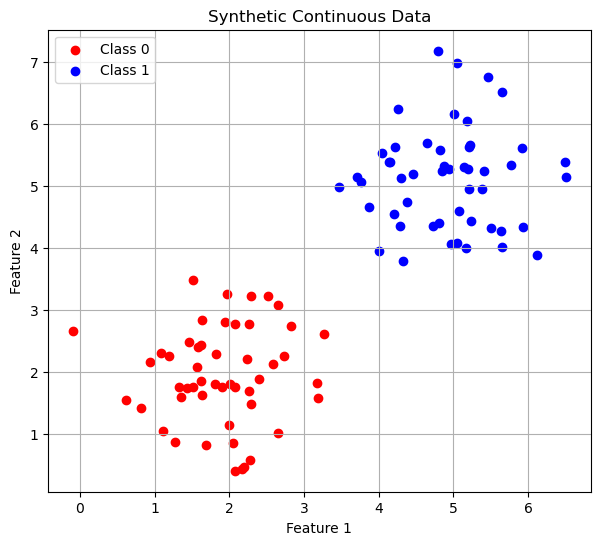

In [7]:
# Setting a seed for reproducibility
np.random.seed(42)

# Class 0: centered around (2, 2)
class_0 = np.random.randn(50, 2) * 0.8 + np.array([2, 2])

# Class 1: centered around (5, 5)
class_1 = np.random.randn(50, 2) * 0.8 + np.array([5, 5])

# Combining into one dataset
X = np.vstack((class_0, class_1))
y = np.array([0]*50 + [1]*50)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

# Visualizing
plt.figure(figsize=(7, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')
plt.title("Synthetic Continuous Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Implementing Gaussian Naive Bayes</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's write a class that:
<ol>
<li><b>fit():</b> calculates the mean, variance, and prior probability 
for each feature, for each class.</li>
<li><b>_gaussian_density():</b> computes the Gaussian probability 
density for a given value.</li>
<li><b>predict():</b> for each sample, calculates the score for every 
class and picks the one with the highest score.</li>
</ol>
To avoid multiplying many small probabilities together (which can 
cause numerical underflow), we'll work with <b>log probabilities</b> 
instead - turning all the multiplications into additions, since 
<b>log(a × b) = log(a) + log(b)</b>.
</div>

In [8]:
class GaussianNaiveBayes:
    """
    A Gaussian Naive Bayes classifier implemented from scratch.
    Assumes each feature follows a normal distribution within each class.
    """

    def fit(self, X, y):
        # Getting unique class labels
        self.classes = np.unique(y)
        n_features = X.shape[1]

        # Creating dictionaries to store mean, variance, and prior for each class
        self.mean = {}
        self.var = {}
        self.priors = {}

        # For each class, calculate mean, variance, and prior probability
        for c in self.classes:
            X_c = X[y == c]  # all samples belonging to class c

            self.mean[c] = X_c.mean(axis=0)      # mean of each feature
            self.var[c] = X_c.var(axis=0)        # variance of each feature
            self.priors[c] = X_c.shape[0] / X.shape[0]  # P(class = c)

    def _gaussian_log_density(self, class_label, x):
        """
        Calculates the log of the Gaussian probability density
        for a sample x, given a class.
        """
        mean = self.mean[class_label]
        var = self.var[class_label]

        # Adding a tiny value to variance to avoid division by zero
        var = var + 1e-9

        # Log of the Gaussian formula:
        # log(P(x|C)) = -0.5 * log(2*pi*var) - ((x - mean)^2 / (2*var))
        numerator = -((x - mean) ** 2) / (2 * var)
        denominator = -0.5 * np.log(2 * np.pi * var)

        # Summing across all features (since they're assumed independent)
        return np.sum(numerator + denominator)

    def predict(self, X):
        predictions = []

        # Looping over each sample
        for x in X:
            # Calculating the log score for each class
            log_scores = {}

            for c in self.classes:
                # log(P(C)) + sum of log(P(feature_i | C))
                log_prior = np.log(self.priors[c])
                log_likelihood = self._gaussian_log_density(c, x)
                log_scores[c] = log_prior + log_likelihood

            # Picking the class with the highest log score
            best_class = max(log_scores, key=log_scores.get)
            predictions.append(best_class)

        return np.array(predictions)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Training and Testing the Model</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's train our Gaussian Naive Bayes classifier on the synthetic 
data and check the parameters it learned (mean, variance, and 
priors for each class).
</div>

In [9]:
# Creating and training the model
model = GaussianNaiveBayes()
model.fit(X, y)

# Inspecting what the model learned
for c in model.classes:
    print(f"Class {c}:")
    print(f"  Mean: {model.mean[c]}")
    print(f"  Variance: {model.var[c]}")
    print(f"  Prior: {model.priors[c]:.2f}\n")

Class 0:
  Mean: [1.8914595  1.94238608]
  Variance: [0.43672905 0.6071226 ]
  Prior: 0.50

Class 1:
  Mean: [4.9236377  5.11204964]
  Variance: [0.49195591 0.64279331]
  Prior: 0.50



In [10]:
# Making predictions on the training data
predictions = model.predict(X)

# Calculating accuracy
accuracy = np.mean(predictions == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing the Decision Boundary</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's visualize the regions our model assigns to each class. Unlike 
SVM, Naive Bayes doesn't draw a single straight line - the boundary 
is wherever the Gaussian "bumps" of the two classes have equal 
probability density. This can result in <b>curved boundaries</b>, 
even though we never explicitly used a kernel trick!
</div>

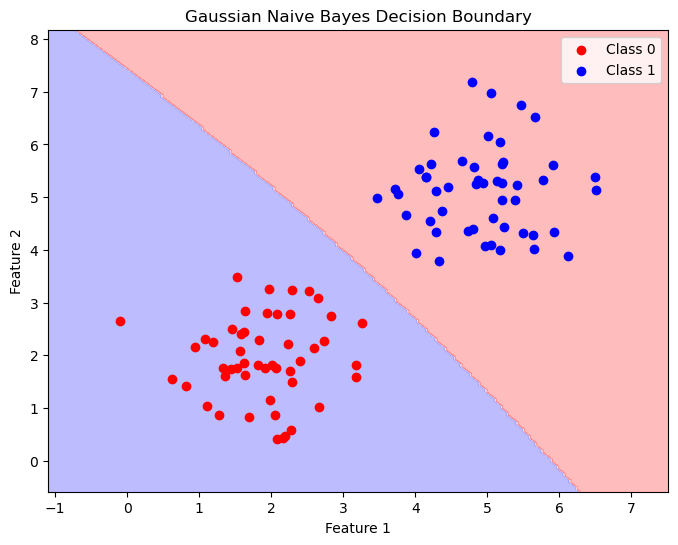

In [11]:
# Creating a mesh grid covering the data range
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

# Predicting the class for every point on the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

plt.title("Gaussian Naive Bayes Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Implemented <b>categorical Naive Bayes by hand</b> on the tennis 
dataset, calculating priors and likelihoods directly from counts.</li>
<li>Identified the <b>zero probability problem</b> and why Laplace 
smoothing (or similar techniques) is needed in practice.</li>
<li>Built a general-purpose <b>Gaussian Naive Bayes class</b> for 
continuous features, using the normal distribution to model 
likelihoods.</li>
<li>Used <b>log probabilities</b> to avoid numerical underflow when 
multiplying many small numbers together.</li>
<li>Visualized the decision boundary - which can be 
<b>curved</b>, unlike the straight-line boundary of a linear SVM.</li>
</ul>
Next, I'll apply this Gaussian Naive Bayes implementation (or 
sklearn's version) to a <b>real-world dataset</b> to see how it 
performs in practice.
</div>